In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
results = pd.read_pickle('../sim/data/simulation_results_20260321_231955.pkl')

In [3]:
results.keys()

dict_keys(['runs', 'micro_logs', 'macro_logs', 'opportunity_logs', 'accounts_state', 'opportunities_state', 'leads_state'])

In [4]:
results['runs']['0']['reps']

{'005ak00000TI0yYAAT': {'earnings': 88441.9222658469, 'strategy': 'Closer'},
 '005ak00000TI3rZAAT': {'earnings': 40622.413611617085,
  'strategy': 'Nurturer'},
 '005ak00000TI49JAAT': {'earnings': 70113.71668701537, 'strategy': 'Grinder'},
 '005ak00000TI4KbAAL': {'earnings': 100512.429782716, 'strategy': 'Scattered'}}

In [5]:
rows = []

for run_id, run_data in results['runs'].items():
    accounts = run_data.get("accounts", {})
    # print(accounts)
    # break
#     # build a lookup: account_id -> rep_id
    account_rep = {a_id: a_data.get("rep_id") for a_id, a_data in accounts.items()}
    # print(account_rep)
    for opp_id, opp_data in run_data.get("opportunities", {}).items():
        # get the rep from owning account
        rep_id = opp_data.get("rep_id") 
        
        rows.append({
            "run_id": run_id,
            "opportunity_id": opp_id,
            "rep_id": rep_id,
            "stage_final": opp_data.get("stage_final"),
            "won": opp_data.get("won"),
            "revenue": opp_data.get("revenue", 0),
            'commission': opp_data['commission'],
            "sentiment": opp_data.get("sentiment", 0),
            "sentiment_history": opp_data.get("sentiment_history", []),
            # "sentiment_mean": sentiment_mean,
            # 'sentiment_std': sentiment_std
            
            
        })

# create a DataFrame
opp_df = pd.DataFrame(rows)
    
    
opp_df['run_id'] = opp_df['run_id'].astype(int)

In [6]:
opp_df

,run_id,opportunity_id,rep_id,stage_final,won,revenue,commission,sentiment,sentiment_history
0,0,4edb28b7-1424-49c0-9c8c-47f5d3e0a6d3,005ak00000TI49JAAT,Closed Dead,False,10463.578199,523.180000,-1.799264,"[-0.14500000000000002, -0.14500000000000002, -..."
1,0,39af9889-51eb-41b6-b93a-faf6fed6aa32,005ak00000TI4KbAAL,Closed Lost,False,85546.382203,4277.320000,0.944153,"[-0.119, -0.119, 0.028133288860189898, -0.2484..."
2,0,05f72a26-065e-4448-85cd-2c6163852cb9,005ak00000TI49JAAT,Closed Dead,False,35120.289181,1756.010000,-1.335099,"[-0.14500000000000002, -0.14500000000000002, -..."
3,0,3831c109-bc7e-4e5e-b93e-e3ecd4e31a0b,005ak00000TI4KbAAL,Closed Dead,False,15016.622480,750.830000,-0.678207,"[0.10737788086130354, 0.11257618356101289, -0...."
4,0,d27e3c41-0bbd-4df8-8c26-aaeb092ea9cc,005ak00000TI3rZAAT,Closed Won,True,14642.285456,732.114273,-0.413404,"[-0.20484608097775636, -0.37354057562031634, -..."
...,...,...,...,...,...,...,...,...,...
1110,4,255e8848-fee2-4b7d-8041-ac30555af6c3,005ak00000TI4KbAAL,Proposal,False,125222.489094,6261.120000,-0.324045,"[1.1918364961649908, -1.271617049335928, -1.26..."
1111,4,9fd895a7-41f8-4d33-a617-863dba19cf0c,005ak00000TI3rZAAT,Prospecting,False,40117.978476,2005.900000,-0.027017,"[-0.161, -0.161, -0.161, -0.161, -0.161]"
1112,4,b4bc968b-31a9-4662-8076-12b457a74c76,005ak00000TI4KbAAL,Qualification,False,50758.903196,2537.950000,-0.879174,"[0.2698565852925469, -0.3538594981903136, -0.5..."
1113,4,58675fc7-51ab-4530-b96b-ebc09e7d1996,005ak00000TI49JAAT,Prospecting,False,6832.270639,341.610000,-0.570759,"[-0.161, -0.161, -0.161, -0.161]"


In [7]:
rows = []

for run_id, run_data in results['runs'].items():
    accounts = run_data.get("accounts", {})
    
    # build a lookup: account_id -> rep_id
    # account_rep = {a_id: a_data.get("rep_id") for a_id, a_data in accounts.items()}
    
    for opp_id, opp_data in run_data.get("leads", {}).items():
        # get the rep from owning account
        rep_id = opp_data.get("rep_id")
        # if opportunity doesn't store account_id, you'll need to map differently
        
        
        
        
        history = opp_data.get("sentiment_history", [])
        n = len(history)

        sentiment_mean = sum(history) / max(n, 1)

        if n > 1:
            sentiment_var = sum((x - sentiment_mean) ** 2 for x in history) / (n - 1)
            sentiment_std = sentiment_var ** 0.5
        else:
            sentiment_std = 0

        
        
        
        
        
        
        rows.append({
            "run_id": run_id,
            "opportunity_id": opp_id,
            "rep_id": rep_id,
            "stage_final": opp_data.get("stage_final"),
            "won": opp_data.get("converted"),
            "revenue": opp_data.get("revenue", 0),
            'commission': opp_data.get('commission', 0),
            "sentiment": opp_data.get("sentiment", 0),
            "sentiment_history": opp_data.get("sentiment_history", []),
            # "sentiment_mean": sentiment_mean,
            # 'sentiment_std': sentiment_std
        })

# create a DataFrame
lead_df = pd.DataFrame(rows)
lead_df['run_id'] = lead_df['run_id'].astype(int)

In [8]:
# df = opp_df
opps_df = pd.concat([lead_df, opp_df])
# df = df[
#     df['stage_final'].isin(['Closed Lost', 'Closed Won', 'Closed Converted', 'Closed Dead'])
# ].copy().reset_index(drop = True)

In [9]:
opps_df

,run_id,opportunity_id,rep_id,stage_final,won,revenue,commission,sentiment,sentiment_history
0,0,BAIZSUOO,005ak00000TI49JAAT,Closed Dead,False,4.072784e+06,None,-2.228953,"[0.5333228985271309, -0.7695943727901103, 0.01..."
1,0,WBQHE8N1,005ak00000TI4KbAAL,Closed Lost,False,7.719355e+06,None,-0.607520,"[-0.176, -0.22727361398885682, -0.556292771696..."
2,0,KIZKD2NC,005ak00000TI49JAAT,Closed Dead,False,4.816872e+06,None,-1.633061,"[-0.07769919273613989, -0.5816512482436729, -0..."
3,0,SGGBZV1F,005ak00000TI49JAAT,Closed Lost,False,6.860245e+06,None,-1.543323,"[-0.45516619305086875, -1.1611966684363135, -0..."
4,0,H4ZCOZ7G,005ak00000TI49JAAT,Closed Lost,False,9.568894e+04,None,-1.012617,"[-0.16600000000000004, -0.16600000000000004, -..."
...,...,...,...,...,...,...,...,...,...
1110,4,255e8848-fee2-4b7d-8041-ac30555af6c3,005ak00000TI4KbAAL,Proposal,False,1.252225e+05,6261.12,-0.324045,"[1.1918364961649908, -1.271617049335928, -1.26..."
1111,4,9fd895a7-41f8-4d33-a617-863dba19cf0c,005ak00000TI3rZAAT,Prospecting,False,4.011798e+04,2005.9,-0.027017,"[-0.161, -0.161, -0.161, -0.161, -0.161]"
1112,4,b4bc968b-31a9-4662-8076-12b457a74c76,005ak00000TI4KbAAL,Qualification,False,5.075890e+04,2537.95,-0.879174,"[0.2698565852925469, -0.3538594981903136, -0.5..."
1113,4,58675fc7-51ab-4530-b96b-ebc09e7d1996,005ak00000TI49JAAT,Prospecting,False,6.832271e+03,341.61,-0.570759,"[-0.161, -0.161, -0.161, -0.161]"


In [10]:
macro = pd.DataFrame(results['macro_logs'])

macro = macro.sort_values(["run_id", "entity_id", "day"])

macro["next_day"] = (
    macro
    .groupby(["run_id", "entity_id"])["day"]
    .shift(-1)
)

macro['days_in_stage'] = macro['next_day'] - macro['day']


micro = pd.DataFrame(results['micro_logs'])

In [11]:
macro['macro_name'].unique()

array(['Random Buy Opportunity', 'Advance Stage', 'Decay / Lost',
       'New Lead', 'Lead Advance Stage', 'Spawn Opportunity',
       'Close Opportunity', 'Base Opportunity Created', 'Lead Conversion',
       'Lead Created', 'Spawn Account'], dtype=object)

(array([  7.,  24.,  80., 141., 186., 280., 214.,  89.,  69.,  25.]),
 array([ 3.89792408,  4.55381505,  5.20970601,  5.86559697,  6.52148794,
         7.1773789 ,  7.83326987,  8.48916083,  9.1450518 ,  9.80094276,
        10.45683373]),
 <a list of 10 Patch objects>)

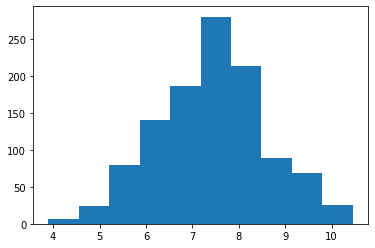

In [12]:
plt.hist(np.log(opp_df['commission']))

In [13]:
macro['macro_name'].value_counts()

Advance Stage               2475
Decay / Lost                1912
New Lead                    1767
Lead Advance Stage          1515
Random Buy Opportunity       861
Close Opportunity            696
Lead Conversion              204
Spawn Opportunity            204
Spawn Account                204
Base Opportunity Created      50
Lead Created                  20
Name: macro_name, dtype: int64

In [14]:
micro['action'].value_counts()

hold_meeting             28800
internal_prep            27221
send_email               21223
make_call                17253
follow_up                16248
research_account         11749
solution_design           3463
stakeholder_alignment     1459
send_proposal             1202
Name: action, dtype: int64

(array([  980.,  1520.,  4167., 12094., 38067., 46778., 15036.,  3498.,
         1446.,  1185.]),
 array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5]),
 <a list of 10 Patch objects>)

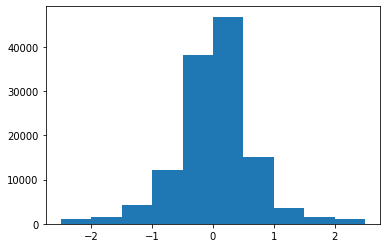

In [15]:
plt.hist(micro['sentiment_delta'])

(array([  780.,  1572.,  5333., 23439., 52826., 30814.,  7137.,  2085.,
          605.,   180.]),
 array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.]),
 <a list of 10 Patch objects>)

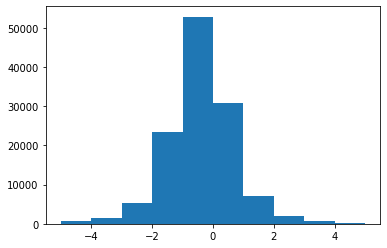

In [16]:
plt.hist(micro['sentiment_total'])

Advance Stage


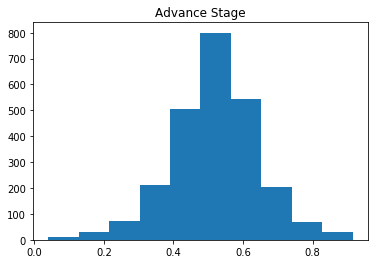

Close Opportunity


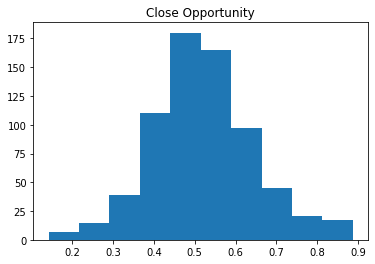

Decay / Lost


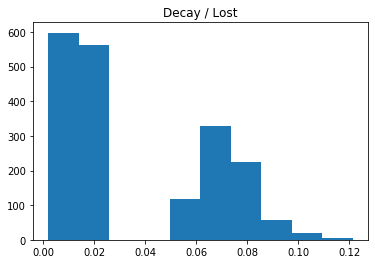

Lead Conversion


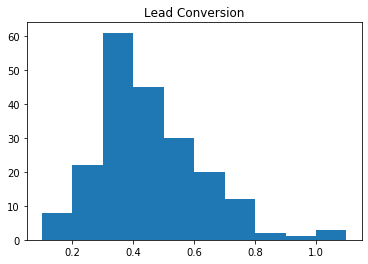

In [17]:
for m in ['Advance Stage', 'Close Opportunity', 'Decay / Lost', 'Lead Conversion']:
    print(m)
    plt.hist(macro[macro['macro_name'] == m]['probability'])
    plt.title(m)
    plt.show()

In [18]:
# crash()

(array([1933.,   85.,  343., 1036., 2029., 1288.,  369.,  105.,   13.,
           9.]),
 array([0.0021 , 0.11189, 0.22168, 0.33147, 0.44126, 0.55105, 0.66084,
        0.77063, 0.88042, 0.99021, 1.1    ]),
 <a list of 10 Patch objects>)

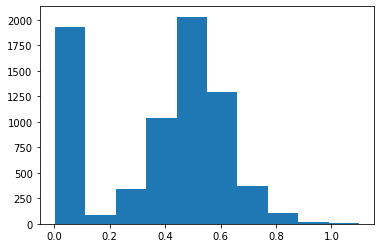

In [19]:
plt.hist(macro['probability'])

In [20]:
macro.columns

Index(['day', 'rep_id', 'entity_id', 'macro_name', 'advanced', 'old_stage',
       'new_stage', 'probability', 'run_id', 'next_day', 'days_in_stage'],
      dtype='object')

In [21]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
from scipy.stats import linregress
import statsmodels.formula.api as smf


# ==================================================================
# PART 1 — Build terminal state feature dataframe
# Input:  opps_df (raw sim snapshot), macro, micro
# Output: deals  (cleaned terminal state, one row per entity × run)
# ==================================================================

def _action_diversity(micro_opp):
    ALL_ACTIONS = {
        "send_email", "make_call", "hold_meeting", "follow_up",
        "send_proposal", "internal_prep", "research_account",
        "solution_design", "stakeholder_alignment",
    }
    if micro_opp.empty:
        return 0.0
    return len(set(micro_opp["action"].unique()) & ALL_ACTIONS) / len(ALL_ACTIONS)

def _momentum_slope(micro_opp):
    sub = micro_opp[["day", "sentiment_total"]].dropna()
    if len(sub) < 2:
        return 0.0
    slope, *_ = linregress(sub["day"], sub["sentiment_total"])
    return float(slope)

def _touch_recency(micro_opp, close_day):
    if micro_opp.empty:
        return float(close_day)
    return float(close_day - micro_opp["day"].max())

def _stall_count(micro_opp, threshold=5):
    if micro_opp.empty:
        return 0
    days = np.sort(micro_opp["day"].unique())
    if len(days) < 2:
        return 0
    return int((np.diff(days) > threshold).sum())

def _activity_cv(activity_per_stage):
    if len(activity_per_stage) < 2:
        return 0.0
    arr = np.array(activity_per_stage, dtype=float)
    mean = arr.mean()
    return 0.0 if mean == 0 else float(arr.std(ddof=1) / mean)

def _success_rate(micro_opp):
    if micro_opp.empty:
        return 0.0
    return float(micro_opp["success"].mean())

def _prop_late_actions(micro_opp, close_day, window=15):
    if micro_opp.empty:
        return 0.0
    return float((micro_opp["day"] >= close_day - window).sum() / len(micro_opp))


def build_deals(opps_df, macro, micro, n_runs=25, stall_threshold=5, late_window=15):
    """
    Build cleaned terminal-state feature dataframe.

    Parameters
    ----------
    opps_df : raw opportunity/lead snapshot from sim results
    macro   : macro event log
    micro   : micro action log
    n_runs  : number of simulation runs to process

    Returns
    -------
    deals : one row per entity × run, with stage, activity, and sentiment features
    """
    STAGE_ORDER = ["Prospecting", "Qualification", "Proposal", "Negotiation"]
    ACTION_TYPES = [
        "send_email", "make_call", "hold_meeting", "follow_up",
        "send_proposal", "internal_prep", "research_account",
        "solution_design", "stakeholder_alignment",
    ]
    records = []

    for run_id in tqdm(range(n_runs)):
        run_snap  = opps_df[opps_df["run_id"] == run_id]
        run_macro = macro[macro["run_id"] == run_id]
        run_micro = micro[micro["run_id"] == run_id]

        for op in run_snap["opportunity_id"].unique():
            snap      = run_snap[run_snap["opportunity_id"] == op]
            opp_macro = run_macro[run_macro["entity_id"] == op].sort_values("day")
            opp_micro = run_micro[run_micro["entity_id"] == op].sort_values("day")

            if opp_macro.empty:
                continue

            # --- Identity ---
            rep_id      = snap["rep_id"].iloc[0]
            revenue     = snap["revenue"].iloc[0]
            commission  = snap["commission"].iloc[0]
            stage_final = snap["stage_final"].iloc[0]
            won         = bool(snap["won"].iloc[0])
            is_lead     = opp_macro["macro_name"].str.contains("Lead", na=False).any()

            # --- Stage features ---
            stage_rows = opp_macro[
                ~opp_macro["new_stage"].str.contains("Closed", na=False)
            ].copy()
            if stage_rows.empty:
                stage_rows = opp_macro.iloc[[0]]

            n_stages          = len(stage_rows)
            days_per_stage    = stage_rows["days_in_stage"].dropna().values
            avg_days_in_stage = float(np.mean(days_per_stage))    if len(days_per_stage) > 0 else 0.0
            max_days_in_stage = float(np.max(days_per_stage))     if len(days_per_stage) > 0 else 0.0
            days_in_stage_cv  = (
                float(np.std(days_per_stage, ddof=1) / np.mean(days_per_stage))
                if len(days_per_stage) > 1 and np.mean(days_per_stage) > 0 else 0.0
            )

            close_day  = int(opp_macro["day"].max())
            open_day   = int(opp_macro["day"].min())
            cycle_time = close_day - open_day

            deepest = stage_rows["new_stage"].map(
                {s: i for i, s in enumerate(STAGE_ORDER)}
            ).max()
            pipeline_depth = (float(deepest) / (len(STAGE_ORDER) - 1)) if pd.notna(deepest) else 0.0

            # --- Per-stage activity ---
            activity_per_stage = []
            for _, sr in stage_rows.iterrows():
                start = sr["day"]
                end   = sr["next_day"] if pd.notna(sr["next_day"]) else close_day
                activity_per_stage.append(
                    opp_micro[(opp_micro["day"] >= start) & (opp_micro["day"] < end)].shape[0]
                )

            activity_count      = len(opp_micro)
            avg_micro_per_stage = float(np.mean(activity_per_stage)) if activity_per_stage else 0.0
            early_activity      = activity_per_stage[0]  if activity_per_stage else 0
            late_activity       = activity_per_stage[-1] if activity_per_stage else 0
            activity_cv         = _activity_cv(activity_per_stage)
            activity_velocity   = activity_count / cycle_time if cycle_time > 0 else 0.0
            stage_velocity      = n_stages / cycle_time       if cycle_time > 0 else 0.0

            # --- Action quality ---
            total_actions     = max(activity_count, 1)
            action_diversity  = _action_diversity(opp_micro)
            success_rate      = _success_rate(opp_micro)
            momentum_slope    = _momentum_slope(opp_micro)
            touch_recency     = _touch_recency(opp_micro, close_day)
            stall_count       = _stall_count(opp_micro, threshold=stall_threshold)
            prop_late_actions = _prop_late_actions(opp_micro, close_day, window=late_window)
            action_fracs      = {
                f"frac_{a}": opp_micro[opp_micro["action"] == a].shape[0] / total_actions
                for a in ACTION_TYPES
            }

            # --- Sentiment ---
            hist_lists  = snap["sentiment_history"].tolist()
            all_history = [s for sub in hist_lists for s in sub]
            sentiment_final  = float(snap["sentiment"].iloc[-1])
            sentiment_median = float(np.median(all_history))          if all_history else np.nan
            sentiment_std    = float(np.std(all_history, ddof=1))     if len(all_history) > 1 else 0.0
            sentiment_range  = float(np.max(all_history) - np.min(all_history)) if len(all_history) > 1 else 0.0

            records.append({
                "run_id": run_id, "entity": f"{op}_{run_id}",
                "rep_id": rep_id, "is_lead": is_lead,
                "won": won, "stage_final": stage_final,
                "revenue": revenue, "commission": commission,
                "n_stages": n_stages, "pipeline_depth": pipeline_depth,
                "avg_days_in_stage": avg_days_in_stage,
                "max_days_in_stage": max_days_in_stage,
                "days_in_stage_cv": days_in_stage_cv,
                "cycle_time": cycle_time,
                "activity_count": activity_count,
                "avg_micro_per_stage": avg_micro_per_stage,
                "early_activity": early_activity, "late_activity": late_activity,
                "activity_cv": activity_cv,
                "activity_velocity": activity_velocity, "stage_velocity": stage_velocity,
                "action_diversity": action_diversity, "success_rate": success_rate,
                "momentum_slope": momentum_slope, "touch_recency": touch_recency,
                "stall_count": stall_count, "prop_late_actions": prop_late_actions,
                "sentiment_final": sentiment_final, "sentiment_median": sentiment_median,
                "sentiment_std": sentiment_std, "sentiment_range": sentiment_range,
                **action_fracs,
            })

    return pd.DataFrame(records)


# ==================================================================
# PART 2 — Sentiment effect sizes + time series
# Input:  deals (output of build_deals), macro, micro
# Output: raw, adjusted, by_stage, timeseries
# ==================================================================

def _enrich_micro(micro, macro, deals):
    m = micro[micro["success"] == True].copy()

    stage_windows = (
        macro[~macro["new_stage"].str.contains("Closed", na=False)]
        [["run_id", "entity_id", "new_stage", "day", "next_day"]]
        .rename(columns={"day": "stage_start", "next_day": "stage_end"})
        .copy()
    )
    stage_windows["stage_end"] = stage_windows["stage_end"].fillna(99999)

    m = m.merge(stage_windows, on=["run_id", "entity_id"], how="left")
    m = m[(m["day"] >= m["stage_start"]) & (m["day"] < m["stage_end"])].copy()
    m["stage"] = m["new_stage"].fillna("Pre-Stage")
    m = m.drop(columns=["new_stage", "stage_start", "stage_end"])

    outcome = deals[["entity", "won", "is_lead"]].copy()
    outcome["entity_id"] = outcome["entity"].str.rsplit("_", n=1).str[0]
    outcome["run_id"]    = outcome["entity"].str.rsplit("_", n=1).str[1].astype(int)
    outcome = outcome.drop(columns=["entity"])

    m = m.merge(outcome, on=["run_id", "entity_id"], how="left")
    return m


def _raw_effects(m):
    records = []
    for action, grp in m.groupby("action"):
        deltas = grp["sentiment_delta"].dropna().values
        n = len(deltas)
        if n == 0:
            continue
        mean, median = deltas.mean(), np.median(deltas)
        std  = deltas.std(ddof=1) if n > 1 else 0.0
        se   = std / np.sqrt(n)
        tc   = stats.t.ppf(0.975, df=max(n - 1, 1))
        records.append({
            "action": action, "n": n,
            "mean_delta": round(mean, 4), "median_delta": round(median, 4),
            "std_delta": round(std, 4),
            "ci_lower": round(mean - tc * se, 4), "ci_upper": round(mean + tc * se, 4),
            "ci_width": round(2 * tc * se, 4),
        })
    return pd.DataFrame(records).sort_values("mean_delta", ascending=False).reset_index(drop=True)


def _adjusted_effects(m):
    m2 = m.copy()
    m2["action"] = pd.Categorical(
        m2["action"],
        categories=["send_email"] + [a for a in sorted(m2["action"].unique()) if a != "send_email"]
    )
    m2["stage"]      = pd.Categorical(m2["stage"])
    m2["won"]        = m2["won"].astype(int)
    m2["run_id_cat"] = m2["run_id"].astype(str)

    try:
        model = smf.ols(
            "sentiment_delta ~ C(action) + C(stage) + C(won) + C(run_id_cat)",
            data=m2
        ).fit()
    except Exception as e:
        print(f"OLS failed: {e}")
        return pd.DataFrame()

    params, conf, pvals, se = model.params, model.conf_int(), model.pvalues, model.bse

    records = [{
        "action": "send_email (baseline)",
        "coef": round(params["Intercept"], 4), "se": round(se["Intercept"], 4),
        "t": round(model.tvalues["Intercept"], 3), "p_value": round(pvals["Intercept"], 4),
        "ci_lower": round(conf.loc["Intercept", 0], 4),
        "ci_upper": round(conf.loc["Intercept", 1], 4),
        "significant": pvals["Intercept"] < 0.05,
    }]
    for idx in [i for i in params.index if i.startswith("C(action)")]:
        action_name = idx.split("[T.")[-1].rstrip("]")
        records.append({
            "action": action_name,
            "coef": round(params[idx], 4), "se": round(se[idx], 4),
            "t": round(model.tvalues[idx], 3), "p_value": round(pvals[idx], 4),
            "ci_lower": round(conf.loc[idx, 0], 4), "ci_upper": round(conf.loc[idx, 1], 4),
            "significant": pvals[idx] < 0.05,
        })

    result = pd.DataFrame(records).sort_values("coef", ascending=False).reset_index(drop=True)
    result["r_squared"] = round(model.rsquared, 4)
    return result


def _stage_effects(m):
    records = []
    for (action, stage), grp in m.groupby(["action", "stage"]):
        deltas = grp["sentiment_delta"].dropna().values
        n = len(deltas)
        if n == 0:
            continue
        mean = deltas.mean()
        std  = deltas.std(ddof=1) if n > 1 else 0.0
        se   = std / np.sqrt(n)
        tc   = stats.t.ppf(0.975, df=max(n - 1, 1))
        records.append({
            "action": action, "stage": stage, "n": n,
            "mean_delta": round(mean, 4),
            "ci_lower": round(mean - tc * se, 4), "ci_upper": round(mean + tc * se, 4),
            "reliable": n >= 5,
        })
    return (
        pd.DataFrame(records)
        .sort_values(["action", "mean_delta"], ascending=[True, False])
        .reset_index(drop=True)
    )


def _sentiment_timeseries(m, deals):
    cycle = deals[["entity", "cycle_time", "won", "is_lead"]].copy()
    cycle["entity_id"] = cycle["entity"].str.rsplit("_", n=1).str[0]
    cycle["run_id"]    = cycle["entity"].str.rsplit("_", n=1).str[1].astype(int)
    cycle = cycle.drop(columns=["entity"])

    # Drop won/is_lead already on m from _enrich_micro before re-joining
    m2 = m.drop(columns=["won", "is_lead"], errors="ignore")
    m2 = m2.merge(
        cycle[["run_id", "entity_id", "cycle_time", "won", "is_lead"]],
        on=["run_id", "entity_id"], how="left",
    )

    day_agg = (
        m2.groupby(["run_id", "entity_id", "day", "won", "is_lead", "cycle_time"])
        .agg(
            mean_delta      = ("sentiment_delta", "mean"),
            sum_delta       = ("sentiment_delta", "sum"),
            sentiment_level = ("sentiment_total", "last"),
            n_actions       = ("action", "count"),
        )
        .reset_index()
    )

    day_agg["t_norm"] = np.where(
        day_agg["cycle_time"] > 0,
        day_agg["day"] / day_agg["cycle_time"], 0.0
    ).clip(0, 1)

    return day_agg.sort_values(["run_id", "entity_id", "day"]).reset_index(drop=True)


def build_sentiment_effects(micro, macro, deals):
    """
    Parameters
    ----------
    micro  : micro log
    macro  : macro log
    deals  : output of build_deals()

    Returns
    -------
    raw, adjusted, by_stage, timeseries
    """
    print("Enriching micro log...")
    m = _enrich_micro(micro, macro, deals)
    print(f"  {len(m):,} successful actions retained")

    print("Raw effect sizes...")
    raw = _raw_effects(m)

    print("OLS adjusted effects...")
    adjusted = _adjusted_effects(m)
    if not adjusted.empty:
        print(f"  R² = {adjusted['r_squared'].iloc[0]:.4f}")

    print("Per-stage breakdown...")
    by_stage = _stage_effects(m)

    print("Building sentiment time series...")
    timeseries = _sentiment_timeseries(m, deals)

    return raw, adjusted, by_stage, timeseries


# ==================================================================
# RUN
# opps_df = raw sim snapshot (input, untouched)
# deals   = cleaned terminal state (output)
# ==================================================================

deals = build_deals(opps_df, macro, micro, n_runs=15)

raw, adjusted, by_stage, timeseries = build_sentiment_effects(micro, macro, deals)


  0%|          | 0/15 [00:00<?, ?it/s]/home/simonhans/anaconda3/lib/python3.7/site-packages/scipy/stats/_stats_mstats_common.py:130: RuntimeWarning: invalid value encountered in double_scalars
  slope = r_num / ssxm
/home/simonhans/anaconda3/lib/python3.7/site-packages/scipy/stats/_stats_mstats_common.py:142: RuntimeWarning: divide by zero encountered in double_scalars
  sterrest = np.sqrt((1 - r**2) * ssym / ssxm / df)
100%|██████████| 15/15 [00:42<00:00,  2.84s/it]


Enriching micro log...
  116,314 successful actions retained
Raw effect sizes...
OLS adjusted effects...
  R² = 0.0045
Per-stage breakdown...
Building sentiment time series...


In [22]:
adjusted

,action,coef,se,t,p_value,ci_lower,ci_upper,significant,r_squared
0,stakeholder_alignment,0.3186,0.0182,17.537,0.0000,0.2830,0.3542,True,0.0045
1,internal_prep,0.0269,0.0061,4.376,0.0000,0.0148,0.0389,True,0.0045
2,hold_meeting,-0.0020,0.0060,-0.328,0.7431,-0.0138,0.0098,False,0.0045
3,follow_up,-0.0120,0.0068,-1.758,0.0787,-0.0255,0.0014,False,0.0045
4,make_call,-0.0141,0.0067,-2.097,0.0360,-0.0272,-0.0009,True,0.0045
5,solution_design,-0.0159,0.0126,-1.260,0.2075,-0.0407,0.0088,False,0.0045
6,research_account,-0.0236,0.0075,-3.137,0.0017,-0.0383,-0.0088,True,0.0045
7,send_proposal,-0.1028,0.0218,-4.724,0.0000,-0.1455,-0.0602,True,0.0045
8,send_email (baseline),-0.1376,0.0889,-1.547,0.1218,-0.3119,0.0367,False,0.0045


In [23]:
# Actions with statistically significant effects
adjusted[adjusted["significant"] == True][["action", "coef", "se", "t", "p_value"]]

,action,coef,se,t,p_value
0,stakeholder_alignment,0.3186,0.0182,17.537,0.0000
1,internal_prep,0.0269,0.0061,4.376,0.0000
4,make_call,-0.0141,0.0067,-2.097,0.0360
6,research_account,-0.0236,0.0075,-3.137,0.0017
7,send_proposal,-0.1028,0.0218,-4.724,0.0000


In [24]:
micro

,day,rep_id,entity_id,action,cost,success,attention_remaining,sentiment_delta,sentiment_total,run_id
0,1,005ak00000TI0yYAAT,fac9a02c-5dde-4656-9c3a-06c03264aedd,internal_prep,0,False,332,NaN,NaN,0
1,1,005ak00000TI3rZAAT,18DD1LN5,follow_up,30,True,345,-0.011936,-0.011936,0
2,1,005ak00000TI3rZAAT,d27e3c41-0bbd-4df8-8c26-aaeb092ea9cc,research_account,25,True,320,-0.204846,-0.204846,0
3,1,005ak00000TI3rZAAT,18DD1LN5,follow_up,30,True,290,0.012265,0.000329,0
4,1,005ak00000TI3rZAAT,d27e3c41-0bbd-4df8-8c26-aaeb092ea9cc,hold_meeting,40,True,250,-0.373541,-0.578387,0
...,...,...,...,...,...,...,...,...,...,...
128613,999,005ak00000TI4KbAAL,4033857b-b200-4027-bfb8-1db589af19b4,hold_meeting,40,True,115,-0.437774,-0.958561,4
128614,999,005ak00000TI4KbAAL,4033857b-b200-4027-bfb8-1db589af19b4,follow_up,30,True,85,-0.226753,-1.185313,4
128615,999,005ak00000TI4KbAAL,b4bc968b-31a9-4662-8076-12b457a74c76,follow_up,30,True,55,0.001563,-0.759928,4
128616,999,005ak00000TI4KbAAL,b4bc968b-31a9-4662-8076-12b457a74c76,follow_up,30,True,25,-0.004392,-0.764320,4


In [25]:
adjusted

,action,coef,se,t,p_value,ci_lower,ci_upper,significant,r_squared
0,stakeholder_alignment,0.3186,0.0182,17.537,0.0000,0.2830,0.3542,True,0.0045
1,internal_prep,0.0269,0.0061,4.376,0.0000,0.0148,0.0389,True,0.0045
2,hold_meeting,-0.0020,0.0060,-0.328,0.7431,-0.0138,0.0098,False,0.0045
3,follow_up,-0.0120,0.0068,-1.758,0.0787,-0.0255,0.0014,False,0.0045
4,make_call,-0.0141,0.0067,-2.097,0.0360,-0.0272,-0.0009,True,0.0045
5,solution_design,-0.0159,0.0126,-1.260,0.2075,-0.0407,0.0088,False,0.0045
6,research_account,-0.0236,0.0075,-3.137,0.0017,-0.0383,-0.0088,True,0.0045
7,send_proposal,-0.1028,0.0218,-4.724,0.0000,-0.1455,-0.0602,True,0.0045
8,send_email (baseline),-0.1376,0.0889,-1.547,0.1218,-0.3119,0.0367,False,0.0045


In [26]:
# # Variance explained by each component
# import statsmodels.formula.api as smf

# m_action_only  = smf.ols("sentiment_delta ~ C(action)", data=m2).fit()
# m_stage_only   = smf.ols("sentiment_delta ~ C(stage)",  data=m2).fit()
# m_full         = smf.ols("sentiment_delta ~ C(action) + C(stage) + C(won) + C(run_id_cat)", data=m2).fit()

# print(f"Action alone:  R² = {m_action_only.rsquared:.4f}")
# print(f"Stage alone:   R² = {m_stage_only.rsquared:.4f}")
# print(f"Full model:    R² = {m_full.rsquared:.4f}")
# print(f"Noise floor:   ~{1 - m_full.rsquared:.2%} of variance is irreducible stochastic noise")

In [27]:
deals.to_pickle('../sim/data/df.pkl')

In [28]:
deals

,run_id,entity,rep_id,is_lead,won,stage_final,revenue,commission,n_stages,pipeline_depth,...,sentiment_range,frac_send_email,frac_make_call,frac_hold_meeting,frac_follow_up,frac_send_proposal,frac_internal_prep,frac_research_account,frac_solution_design,frac_stakeholder_alignment
0,0,BAIZSUOO_0,005ak00000TI49JAAT,True,False,Closed Dead,4.072784e+06,NaN,2,0.000000,...,3.712332,0.218045,0.112782,0.150376,0.180451,0.0,0.157895,0.180451,0.00,0.0
1,0,WBQHE8N1_0,005ak00000TI4KbAAL,True,False,Closed Lost,7.719355e+06,NaN,2,0.000000,...,3.320825,0.269231,0.269231,0.076923,0.115385,0.0,0.076923,0.192308,0.00,0.0
2,0,KIZKD2NC_0,005ak00000TI49JAAT,True,False,Closed Dead,4.816872e+06,NaN,2,0.000000,...,2.778847,0.214286,0.125000,0.142857,0.160714,0.0,0.196429,0.160714,0.00,0.0
3,0,SGGBZV1F_0,005ak00000TI49JAAT,True,False,Closed Lost,6.860245e+06,NaN,2,0.000000,...,2.619922,0.129032,0.129032,0.258065,0.129032,0.0,0.193548,0.161290,0.00,0.0
4,0,H4ZCOZ7G_0,005ak00000TI49JAAT,True,False,Closed Lost,9.568894e+04,NaN,2,0.000000,...,5.000000,0.221477,0.120805,0.187919,0.161074,0.0,0.255034,0.053691,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2897,4,255e8848-fee2-4b7d-8041-ac30555af6c3_4,005ak00000TI4KbAAL,False,False,Proposal,1.252225e+05,6261.12,2,0.666667,...,4.491196,0.280000,0.160000,0.220000,0.020000,0.1,0.080000,0.060000,0.08,0.0
2898,4,9fd895a7-41f8-4d33-a617-863dba19cf0c_4,005ak00000TI3rZAAT,False,False,Prospecting,4.011798e+04,2005.90,1,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00,0.0
2899,4,b4bc968b-31a9-4662-8076-12b457a74c76_4,005ak00000TI4KbAAL,False,False,Qualification,5.075890e+04,2537.95,2,0.333333,...,1.838943,0.307692,0.153846,0.153846,0.230769,0.0,0.076923,0.076923,0.00,0.0
2900,4,58675fc7-51ab-4530-b96b-ebc09e7d1996_4,005ak00000TI49JAAT,False,False,Prospecting,6.832271e+03,341.61,1,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00,0.0


In [29]:
deals[deals['commission'].isna()]['stage_final'].value_counts()

Closed Dead         786
Closed Lost         751
Closed Converted    204
Lead Qualified       43
Lead                  3
Name: stage_final, dtype: int64

In [30]:
deals['stage_final'].value_counts()

Closed Dead         1161
Closed Lost         1078
Closed Won           369
Closed Converted     204
Lead Qualified        43
Prospecting           20
Proposal              14
Qualification          9
Lead                   3
Negotiation            1
Name: stage_final, dtype: int64

In [31]:
deals['stage_final'].value_counts()

Closed Dead         1161
Closed Lost         1078
Closed Won           369
Closed Converted     204
Lead Qualified        43
Prospecting           20
Proposal              14
Qualification          9
Lead                   3
Negotiation            1
Name: stage_final, dtype: int64